## A first agent: tabular Q-learning

We have an environment but nothing to act in it. The simplest learning agent we can put in front of `MicrobeGridEnv` is **tabular Q-learning** (Watkins, 1989), which you have already studied theoretically in the introductory part of the course. This section is a short reminder, framed in the way we will translate it to code in a moment.

### What Q-learning learns

Q-learning estimates the **optimal action-value function**

$$q_\star(s, a) = \mathbb{E}\!\left[\, \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \,\Big|\, S_t = s, A_t = a, \pi_\star \right],$$

the expected discounted return obtained by taking action $a$ in state $s$ and acting optimally thereafter. Knowing $q_\star$ is enough to act optimally, because the greedy policy with respect to $q_\star$ is optimal: $\pi_\star(s) \in \arg\max_a q_\star(s, a)$.

In the tabular setting — finite $\mathcal{S}$ and $\mathcal{A}$ — we represent $q_\star$ as a table $Q \in \mathbb{R}^{|\mathcal{S}| \times |\mathcal{A}|}$, one entry per state-action pair. *Learning* means updating the entries of $Q$ from interaction data so that they converge to $q_\star$.

### The update rule

Q-learning is a **temporal-difference** method: after each transition $(S_t, A_t, R_{t+1}, S_{t+1})$ it pushes the current estimate $Q(S_t, A_t)$ towards a one-step *target* that combines the observed reward with a bootstrapped estimate of future return:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ \underbrace{R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')}_{\text{TD target}} - Q(S_t, A_t) \right].$$

Three features are essential and worth pinning down explicitly.

It is a **sample-based update**: it does not require the transition kernel $P$ or the reward function $R$ — only the realised transition. This is exactly what makes the method compatible with the Gymnasium interface, which only lets us *sample* from the environment.

It is **off-policy**. The action $A_t$ that produced the transition was selected by some *behaviour* policy (typically $\varepsilon$-greedy with respect to the current $Q$), but the target uses $\max_{a'} Q(S_{t+1}, a')$ — the value of the *greedy* action at the next state, regardless of which action the behaviour policy will actually take. The agent is, in effect, evaluating the greedy policy while behaving more exploratorily. This is the technical sense of "off-policy" and it is what distinguishes Q-learning from SARSA, which we will see in Lecture 2.

The **bootstrap term must vanish at terminal states**. If $S_{t+1}$ is terminal in the MDP, the true return from there is zero, and the target collapses to the immediate reward $R_{t+1}$ alone. In code this becomes a multiplication by `(1 - terminated)`, never `(1 - done)`: as we discussed, `truncated` does *not* zero the bootstrap factor.

### Behaviour policy: $\varepsilon$-greedy

At every state $S_t$, the agent picks a random action with probability $\varepsilon$ and the greedy action $\arg\max_a Q(S_t, a)$ otherwise. The parameter $\varepsilon$ controls the *exploration–exploitation* trade-off: high values explore widely but exploit poorly; low values exploit aggressively but may miss better policies. In practice $\varepsilon$ is **annealed** from a high initial value to a small floor as the agent gains experience, a schedule that satisfies the *GLIE* condition (Greedy in the Limit with Infinite Exploration) needed for asymptotic convergence guarantees. We will use a simple exponential decay; a linear schedule is an equally common alternative.

### Convergence in one sentence

Under standard conditions — finite MDP, every state-action pair visited infinitely often, learning rate $\alpha_t$ satisfying the Robbins-Monro conditions $\sum_t \alpha_t = \infty$ and $\sum_t \alpha_t^2 < \infty$, GLIE policy — Q-learning's table converges almost surely to $q_\star$. We will not prove this here; we *will* observe it empirically by training on `MicrobeGridEnv` and watching the learning curves.

### What we need to implement

In the next cells we materialise three things, in three modules of the `rlc` package:

- the agent itself (`rlc/agents/q_learning.py`), holding the Q-table and exposing `select_action` and `update` methods;
- a generic training loop (`rlc/utils/training.py`), agnostic to the algorithm — it will work unchanged for SARSA and Monte Carlo in Lecture 2;
- a small set of plotting utilities (`rlc/utils/plotting.py`) for learning curves and learned policies.

The notebook will only orchestrate: instantiate, train, plot, watch the trained microbe.

A few macro-level decisions in `QLearningAgent` are worth a comment.

The interface is deliberately minimal: `select_action(state)` to act, `update(state, action, reward, next_state, terminated)` to learn from a transition, `end_episode()` to perform per-episode bookkeeping. This same triplet works unchanged for SARSA and for Monte Carlo, with the only difference being what each method does internally — SARSA's `update` will need the next action, Monte Carlo's `update` is a no-op while `end_episode` does the actual learning. Adopting a common interface lets the training loop and the plotting utilities be written once and reused across all three agents in Lecture 2.

The Q-learning update closely mirrors the formula written in the previous cell, with one operational subtlety. The bootstrap factor is zeroed out by checking `terminated`, not a generic `done` flag — exactly the rule we discussed when we dissected the `step` API. A truncated transition would still bootstrap, because the next state remains a perfectly valid MDP state we just chose not to keep visiting.

Action selection uses `_argmax_random_tiebreak` rather than `np.argmax`. The reason is purely practical: `np.argmax` returns the first maximiser, which matters when the Q-table has many equal values — in particular at the very beginning of training, when every entry is still equal to `initial_q`. Without random tie-breaking the agent's first few decisions would be entirely deterministic and biased toward action `0`, which on our environment means the microbe consistently bumping against the top wall. Random tie-breaking dissolves this artifact.

The agent owns its own `numpy.random.Generator`, separate from the environment's RNG. This separation is hygienic: re-seeding the agent does not change the environment's stochasticity and vice versa, which makes individual factors of an experiment independently controllable.

Two helper methods, `greedy_policy` and `state_values`, return derived quantities — the greedy action per state and the state-value $V(s) = \max_a Q(s, a)$. They will be the inputs of the policy and value visualisations in the next subsection. They are deliberately not cached: the Q-table changes throughout training, so it is simpler to recompute them on demand than to keep a synchronised mirror.

Finally, the constructor exposes `initial_q` as a parameter. The default value is zero, which is the textbook choice for episodic tasks with non-positive rewards — and ours has step costs of $-1$ and toxic penalties of $-100$. Setting `initial_q` to a *positive* value implements **optimistic initialisation**, a simple but effective trick that encourages the agent to try every state-action pair at least once before settling, because untried actions look more attractive than tried ones until the table corrects itself. We will not use it for our first run, but it is a knob worth knowing about when tuning exploration.

## Training: the agent–environment loop

We have an environment that exposes the Gymnasium API and an agent that exposes a `select_action` / `update` / `end_episode` interface. To make them learn we need a third piece of code that puts the two in dialogue, following the standard *agent–environment loop* — the same diagram you have seen at the very start of the introductory part of the course, now translated into running code.

### What happens in one episode

A single training episode follows a fixed pattern, repeated until termination or truncation.

The episode begins with `obs, info = env.reset()`. The environment samples an initial state from $\rho_0$ and returns the corresponding observation; the agent has not yet acted. The agent's $\varepsilon$ has whatever value the previous episode left it at — the schedule is per-episode, not per-step.

Inside the episode, at every time step:

- the agent picks an action, `action = agent.select_action(obs)`, using its current behaviour policy ($\varepsilon$-greedy with respect to the current Q-table);
- the environment executes the action, `next_obs, reward, terminated, truncated, info = env.step(action)`, advancing one transition;
- the agent updates its Q-table from the realised transition, `agent.update(obs, action, reward, next_obs, terminated)`. Crucially, only `terminated` is passed — `truncated` does not zero the bootstrap, as we discussed when dissecting the `step` API;
- the loop variable advances, `obs = next_obs`, ready for the next iteration.

The episode ends when `terminated or truncated` becomes true. At that point the agent runs its end-of-episode hook, `agent.end_episode()`, which in Q-learning performs the $\varepsilon$ decay. In Monte Carlo, in Lecture 2, the same hook will be where actual learning happens.

### What we want to record

A useful training loop does not just train: it observes. For every episode we will store the *episode return* (the sum of rewards collected) and the *episode length* (number of steps), plus the value of $\varepsilon$ at the end of the episode for diagnostic purposes. These three quantities form the basis of the **learning curves** we plot at the end of training.

### Training performance vs. evaluation performance

There is a subtlety that deserves to be made explicit, because confusing the two is one of the most common pitfalls in empirical RL.

The episode returns collected *during training* are produced by the $\varepsilon$-greedy behaviour policy, which deliberately takes random actions at rate $\varepsilon$. Even after the agent has converged to the optimal Q-table, those episodes will keep showing returns *worse* than optimal, simply because the agent is still being forced to explore. The training learning curve, therefore, measures something halfway between "what the agent has learned" and "how much the agent is currently exploring".

To measure the *quality of what has been learned* we need a separate signal: the return obtained when the agent acts **greedily**, with $\varepsilon$ effectively set to zero, with no learning updates. This is what an *evaluation rollout* does. We will run a small batch of evaluation episodes every `eval_every` training episodes, and we will use the resulting *evaluation curve* — typically much smoother than the training curve — to track learning progress in a clean way. We will see this distinction in action repeatedly throughout the course; it is especially eloquent in Lecture 2, when SARSA and Q-learning will produce *visibly different* gaps between training return and evaluation return.

Both the training loop and the evaluation rollout are best implemented as small reusable utilities in the `rlc` package, since they are entirely algorithm-agnostic — the very same code will drive Q-learning, SARSA, Monte Carlo, and the function approximation agents we will meet later in the course.

### Training the microbe

We can finally see Q-learning in action. We instantiate a fresh `MicrobeGridEnv` and a fresh `QLearningAgent` with default hyperparameters, train for a few hundred episodes, and evaluate the greedy policy periodically along the way. The `TrainingHistory` returned will be the basis of all the plots and animations of the next subsection.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

from rlc.envs.microbe import MicrobeGridEnv
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = MicrobeGridEnv(render_mode="rgb_array")
eval_env = MicrobeGridEnv(render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed=0,
)

history = train(
    agent,
    train_env,
    n_episodes=500,
    max_steps_per_episode=200,
    eval_every=25,
    eval_episodes=20,
    eval_env=eval_env,
    eval_max_steps=200,
    seed=0,
    progress=True,
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")

Final epsilon:                     0.082
Mean return, last 50 train eps:    -52.8
Final greedy evaluation return:    -13.0 (std 0.0)


### Visualising what was learned

The `TrainingHistory` records the full per-episode signal of the run, but signals are not insights until we plot them. Three pictures are useful and we will produce them in this order.

The first is the **training learning curve**: episode return vs. episode index, possibly smoothed. This is the noisiest of the three — every dip is a random action that found a toxic cell — but it is the picture that most directly answers "is the agent learning at all?".

The second is the **evaluation curve**: mean greedy return computed every `eval_every` training episodes. By construction it is far smoother than the training curve, and it is the picture that answers "*how well* has the agent learned at this point in training?". The two curves naturally appear on the same plot, and reading them together is half the diagnostic skill of empirical RL.

The third is the **learned policy and value function**: a 2D heatmap of $V(s) = \max_a Q(s, a)$ over the grid, with arrows showing the greedy action in each cell. This is the picture that answers "*what* did the agent learn?". On our 4×12 grid we expect the heatmap to grade smoothly from low values near the start toward zero at the goal, and the arrows to draw a clear path along the row immediately above the toxic band — the textbook *risky shortcut* that Q-learning is famous for finding.

The plotting helpers go into `rlc/utils/plotting.py`. They are written once and reused across all subsequent lectures: SARSA, Monte Carlo, and the function-approximation methods will produce the same kinds of pictures.

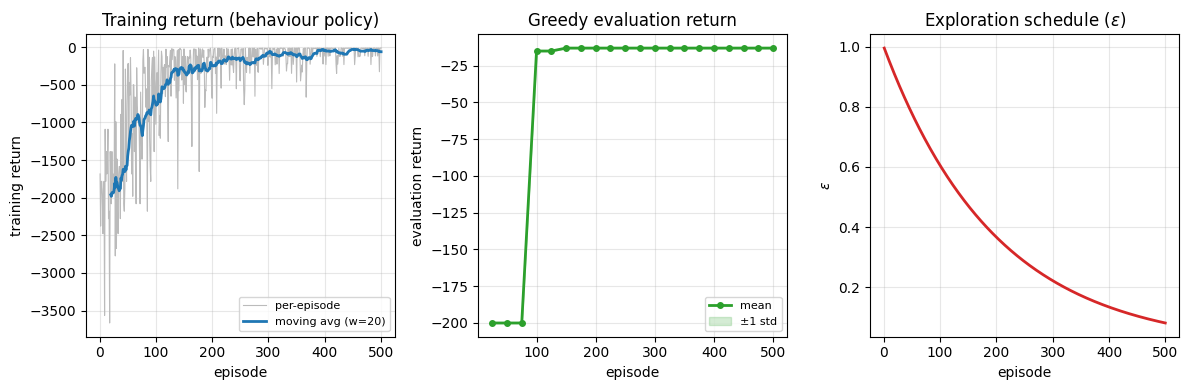

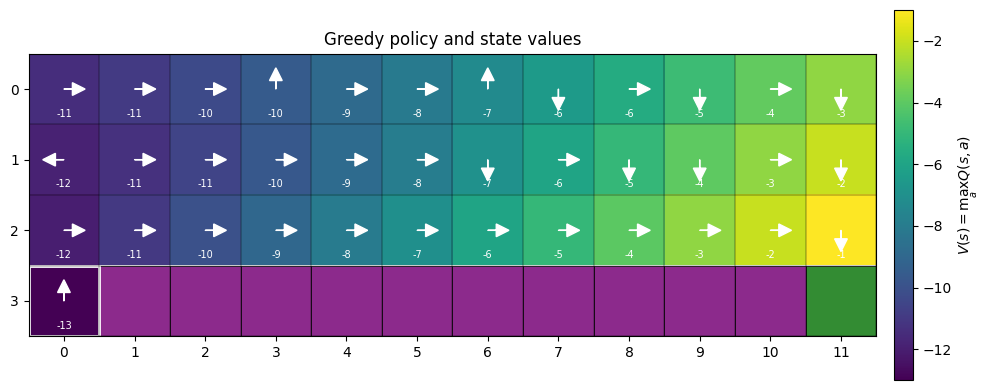

In [10]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True)
plt.show()

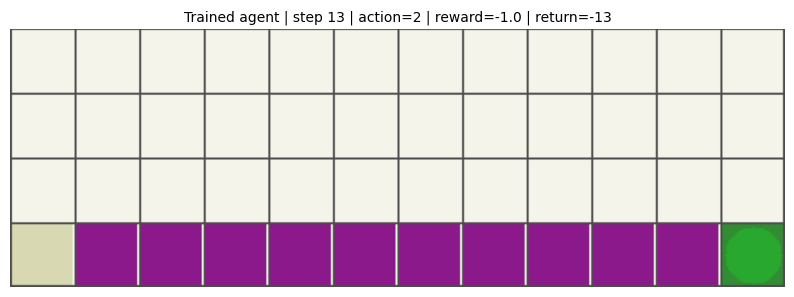

Episode ended after 13 steps with return -13.


In [11]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
MAX_STEPS = 50

# Use the eval_env (already in rgb_array mode) and run a single greedy episode.
obs, info = eval_env.reset(seed=123)
ep_step = 0
ep_return = 0.0

show_frame(eval_env.render(),
           title=f"Trained agent | step 0 | start (obs={obs})")
time.sleep(FRAME_DELAY)

for _ in range(MAX_STEPS):
    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        eval_env.render(),
        title=(f"Trained agent | step {ep_step} | action={action} | "
               f"reward={reward} | return={ep_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        break

print(f"Episode ended after {ep_step} steps with return {ep_return:.0f}.")